# VISUALIZACIÓN PARA LA ANALÍTICA DE DATOS - (203238429A_2204)
---
**Fase 2 - Comonente Practico** <br>
Presentado por: Edwin Yesid Fonseca Ahumada <br>
Grupo: 203238429_7<br>
Código: 80012391<br>
Presentado a: SIXYEL JEYSON CASTAñEDA CORONADO<br>
**Universidad Nacional Abierta y a Distancia – UNAD**<br>
Fecha: Septiembre 2026<br>

## Tabla de contenidos

<div class="alert alert-block alert-info" style="margin-top: 20px">

1. [Introduccion](#0)<br>
2. [Objetivos](#1)<br>
3. [Actividad 1 Preparación del dataset y Análisis Exploratorio de Datos](#2)<br>
4. [Actividad 2 Visualización Geoespacial con Folium](#3)<br>
5. [Actividad 3 Creación de Gráficos Interactivos y Dashboard con Plotly y Dash](#4) <br>
6. [Actividad 4 Completar la Certificación IBM Cognitive](#5) <br>


</div>

# Introduccion<a id="0"></a>

La visualización de datos constituye una herramienta esencial dentro del proceso de analítica, ya que permite transformar grandes volúmenes de información en representaciones gráficas comprensibles y útiles para la toma de decisiones. En esta fase se aplicaran técnicas de visualización mediante el uso de librerías de Python como *Matplotlib*, *Seaborn*, *Folium* y *Plotly*, con el fin de explorar, analizar y comunicar los hallazgos obtenidos a partir del dataset de restaurantes de Colombia.

El desarrollo de esta actividad permitirá fortalecer las competencias en el manejo de herramientas de programación orientadas al análisis visual, fomentando la interpretación crítica de los resultados y la generación de conclusiones basadas en evidencia. Además, se integrarán conceptos de visualización geoespacial e interacción dinámica, elementos clave en la analítica moderna.


# Objetivos<a id="1"></a>

### Objetivo General
Aplicar técnicas de visualización de datos mediante herramientas de programación en Python, con el fin de analizar, interpretar y comunicar información relevante a partir de un dataset, fortaleciendo las competencias en analítica y toma de decisiones.

### Objetivos Específicos
- Preparar y depurar el dataset para garantizar la calidad de la información utilizada en el análisis.
- Realizar un análisis exploratorio de datos (EDA) que permita identificar patrones, tendencias y relaciones significativas.
- Implementar visualizaciones geoespaciales utilizando la librería *Folium* para representar datos en mapas interactivos.
- Diseñar gráficos dinámicos e interactivos con *Plotly* y *Dash*, orientados a la construcción de dashboards informativos.
- Desarrollar habilidades prácticas en el uso de librerías de visualización que faciliten la interpretación crítica de los resultados.


# Actividad 1 Preparación del dataset y Análisis Exploratorio de Datos<a id="2"></a>

* Carga del data set

In [25]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
import geopandas as gpd

In [2]:
# Cargar el dataset desde Excel
dataset = pd.read_excel("Anexo 1 - dataset fase 2.xlsx")

print(dataset.head())

   index  ID         Nombre Categoría  Calificación  Precio promedio (USD)  \
0      0   1  Restaurante 1     China           4.8                     38   
1      1   2  Restaurante 2  Francesa           4.2                     14   
2      2   3  Restaurante 3  Francesa           3.3                     21   
3      3   4  Restaurante 4   Peruana           3.6                     22   
4      4   5  Restaurante 5  Italiana           4.7                     31   

   Número de reseñas  Latitud  Longitud  
0                344     4.67    -74.14  
1                264     3.60    -75.60  
2                252     5.83    -76.09  
3                299     6.26    -74.45  
4                411     4.49    -75.74  


* Análisis estadístico descriptivo de las calificaciones, precios y número de reseñas.

* Al realizar la verificacion del dataset se encontraron valores en la columna latitud con un rango invalido el rango debe estar entre -90 y 90 grados 

*  Se observa que los valores parecen estar multiplicados por un factor muy grande (~1e12). la solucion es dividirlos por 1e12 para llevarlos al rango correcto.

In [3]:
# Inspeccionar los valores de la columna Latitud
print("Valores fuera de rango en Latitud:")
print(dataset[(dataset['Latitud'] < -90) | (dataset['Latitud'] > 90)])



Valores fuera de rango en Latitud:
     index   ID           Nombre   Categoría  Calificación  \
213    213  214  Restaurante 214    Japonesa           3.8   
421    421  422  Restaurante 422     Peruana           4.4   
502    502  503  Restaurante 503  Colombiana           3.7   
525    525  526  Restaurante 526    Mexicana           2.1   
766    766  767  Restaurante 767    Japonesa           4.1   

     Precio promedio (USD)  Número de reseñas       Latitud  Longitud  
213                     28                 72  1.698613e+16    -75.85  
421                     21                358  1.491512e+16    -75.02  
502                     22                473  1.740143e+15    -76.49  
525                     18                446  1.885441e+16    -75.61  
766                     47                413  1.254517e+14    -75.48  


In [4]:
#    Dividimos por 1e12 para llevarlos al rango correcto.
dataset['Latitud'] = dataset['Latitud'] / 1e12

# Verificacion nuevamente de los valores que estén dentro del rango esperado
print("Latitudes corregidas:")
print(dataset[['Latitud', 'Longitud']].head())

Latitudes corregidas:
        Latitud  Longitud
0  4.670000e-12    -74.14
1  3.600000e-12    -75.60
2  5.830000e-12    -76.09
3  6.260000e-12    -74.45
4  4.490000e-12    -75.74


* Se observaron 3 valores promedio por encima del rango de precios. 
* los precios deberían estar en un rango entre 10 y 50 unidades (según los demás registros del dataset).
Por tanto, la mejor estrategia sería reescalar los valores grandes dividiéndolos por 100 o 10,

In [5]:
# Inspeccionar los valores de la columna Precio promedio (USD)
print("Valores fuera de rango en Precio promedio (USD):")
print(dataset[(dataset['Precio promedio (USD)'] > 50)])


Valores fuera de rango en Precio promedio (USD):
     index   ID           Nombre Categoría  Calificación  \
223    223  224  Restaurante 224  Japonesa           2.7   
641    641  642  Restaurante 642     China           2.0   
806    806  807  Restaurante 807  Francesa           2.4   

     Precio promedio (USD)  Número de reseñas       Latitud  Longitud  
223                    999                461  5.230000e-12    -75.24  
641                    500                188  4.880000e-12    -75.82  
806                   1000                126  5.790000e-12    -76.11  


In [6]:
dataset.loc[dataset['Precio promedio (USD)'] > 100, 'Precio promedio (USD)'] = dataset['Precio promedio (USD)'] / 100


C:\Users\edwin\AppData\Local\Temp\ipykernel_18172\629564699.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 9.99  5.   10.  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.loc[dataset['Precio promedio (USD)'] > 100, 'Precio promedio (USD)'] = dataset['Precio promedio (USD)'] / 100


* Se evidencias valores negativos en la columna Precio promedio (USD) lo más lógico es aplicar valor absoluto (abs()), porque seguramente el error fue un signo mal digitado.

In [7]:
# Filtrar precios negativos
precios_negativos = dataset[dataset['Precio promedio (USD)'] < 0]
print("Precios negativos encontrados:")
print(precios_negativos)


Precios negativos encontrados:
     index   ID           Nombre Categoría  Calificación  \
191    191  192  Restaurante 192     China           4.1   
693    693  694  Restaurante 694  Italiana           1.2   

     Precio promedio (USD)  Número de reseñas       Latitud  Longitud  
191                   -5.0                381  4.500000e-12    -74.25  
693                  -10.0                333  5.100000e-12    -75.43  


In [9]:
dataset['Precio promedio (USD)'] = dataset['Precio promedio (USD)'].abs()

print(dataset[['Categoría', 'Precio promedio (USD)']].head(10))

    Categoría  Precio promedio (USD)
0       China                   38.0
1    Francesa                   14.0
2    Francesa                   21.0
3     Peruana                   22.0
4    Italiana                   31.0
5       China                   49.0
6    Francesa                   24.0
7  Colombiana                   22.0
8       China                   10.0
9    Italiana                   47.0


Se identifica inconsistencias en los nombres de las categorías “Fusión?”, “Desconocida”, “Chino”  “Colombian” y Valores nulos. Esto se soluciona con una limpieza de texto para unificar y corregir los valores antes de graficar. Como los restaurantes estan en Colombia las categorias Descoocidas y Fusion? se reasignaron a la categoria colombiana

In [10]:
# Reemplazar valores inconsistentes o erróneos
dataset['Categoría'] = dataset['Categoría'].replace({
    'Fusión?': 'Colombiana',
    'Chino': 'China',
    ' ': 'Colombiana',
    'Desconocida': 'Colombiana',
    'Colombian': 'Colombiana'
})

# Verificar los valores únicos después de la limpieza
print("Categorías únicas después de la limpieza:")
print(dataset['Categoría'].unique())


Categorías únicas después de la limpieza:
['China' 'Francesa' 'Peruana' 'Italiana' 'Colombiana' 'Mexicana'
 'Japonesa']


* Análisis estadístico descriptivo de las calificaciones, precios y número de reseñas.

In [11]:
# columnas de interés
variables = dataset[['Calificación', 'Precio promedio (USD)', 'Número de reseñas']]

# 1. Resumen estadístico general
print("Resumen estadístico descriptivo:")
print(variables.describe())


Resumen estadístico descriptivo:
       Calificación  Precio promedio (USD)  Número de reseñas
count   1000.000000            1000.000000        1000.000000
mean       2.986200              29.431990         272.165000
std        1.160947              11.652448         129.984236
min        1.000000               5.000000          50.000000
25%        2.000000              20.000000         159.750000
50%        3.000000              29.000000         270.000000
75%        4.000000              40.000000         386.250000
max        5.000000              49.000000         499.000000


In [12]:
# 2. Medidas adicionales de tendencia central y dispersión
print("\nMedias:")
print(variables.mean())



Medias:
Calificación               2.98620
Precio promedio (USD)     29.43199
Número de reseñas        272.16500
dtype: float64


In [13]:
print("\nMedianas:")
print(variables.median())



Medianas:
Calificación               3.0
Precio promedio (USD)     29.0
Número de reseñas        270.0
dtype: float64


In [14]:
print("\nDesviaciones estándar:")
print(variables.std())



Desviaciones estándar:
Calificación               1.160947
Precio promedio (USD)     11.652448
Número de reseñas        129.984236
dtype: float64


In [15]:
# 3. Distribución de valores únicos en Calificación
print("\nDistribución de Calificaciones:")
print(variables['Calificación'].value_counts().sort_index())


Distribución de Calificaciones:
Calificación
1.0    11
1.1    23
1.2    27
1.3    28
1.4    27
1.5    22
1.6    24
1.7    30
1.8    27
1.9    27
2.0    21
2.1    28
2.2    26
2.3    28
2.4    26
2.5    20
2.6    24
2.7    32
2.8    18
2.9    26
3.0    19
3.1    22
3.2    28
3.3    21
3.4    30
3.5    32
3.6    27
3.7    31
3.8    13
3.9    20
4.0    26
4.1    27
4.2    28
4.3    24
4.4    18
4.5    26
4.6    20
4.7    20
4.8    28
4.9    29
5.0    16
Name: count, dtype: int64


* Visualizaciones con Matplotlib para entender la distribución de calificaciones, precios y reseñas.

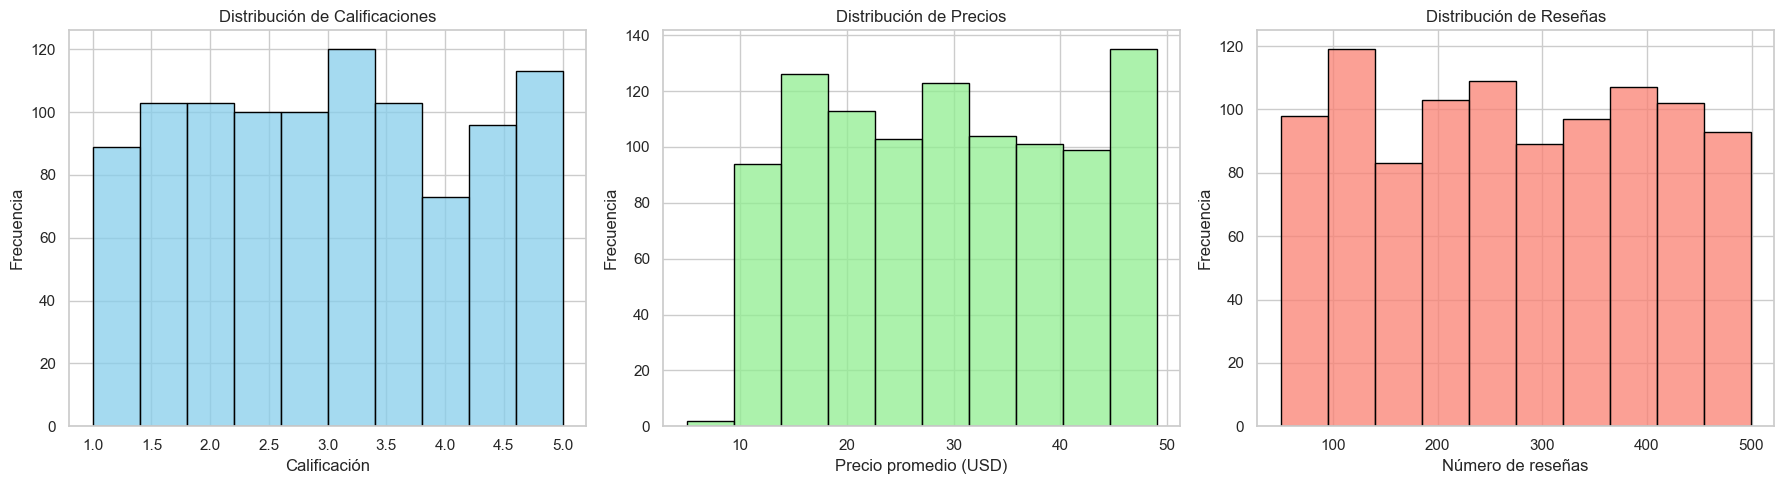

In [16]:
# Activar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Crear las visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Calificaciones
sns.histplot(dataset['Calificación'], bins=10, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribución de Calificaciones')
axes[0].set_xlabel('Calificación')
axes[0].set_ylabel('Frecuencia')

# 2. Precio promedio
sns.histplot(dataset['Precio promedio (USD)'], bins=10, color='lightgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribución de Precios')
axes[1].set_xlabel('Precio promedio (USD)')
axes[1].set_ylabel('Frecuencia')

# 3. Número de reseñas
sns.histplot(dataset['Número de reseñas'], bins=10, color='salmon', edgecolor='black', ax=axes[2])
axes[2].set_title('Distribución de Reseñas')
axes[2].set_xlabel('Número de reseñas')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


* Se puede identificar que las calificaciones estan bastante uniformes entre 1 y 5, sin concentrarse en un rango específico, los restaurantes tienen una variedad amplia de valoraciones, lo que puede indicar diferencias en calidad o experiencia del cliente.<br>

* Los precios promedio se distribuyen entre 10 y 50 USD, con algunos picos en los extremos.Esto indica que hay tanto restaurantes económicos como costosos, pero la mayoría se concentra en un rango medio 20–40 USD.<br>

* La cantidad de reseñas varía entre 0 y 500, con una ligera concentración alrededor de los 100–150 comentarios, esto indica que la mayoría de los restaurantes tienen una visibilidad moderada, mientras unos pocos destacan por su popularidad.

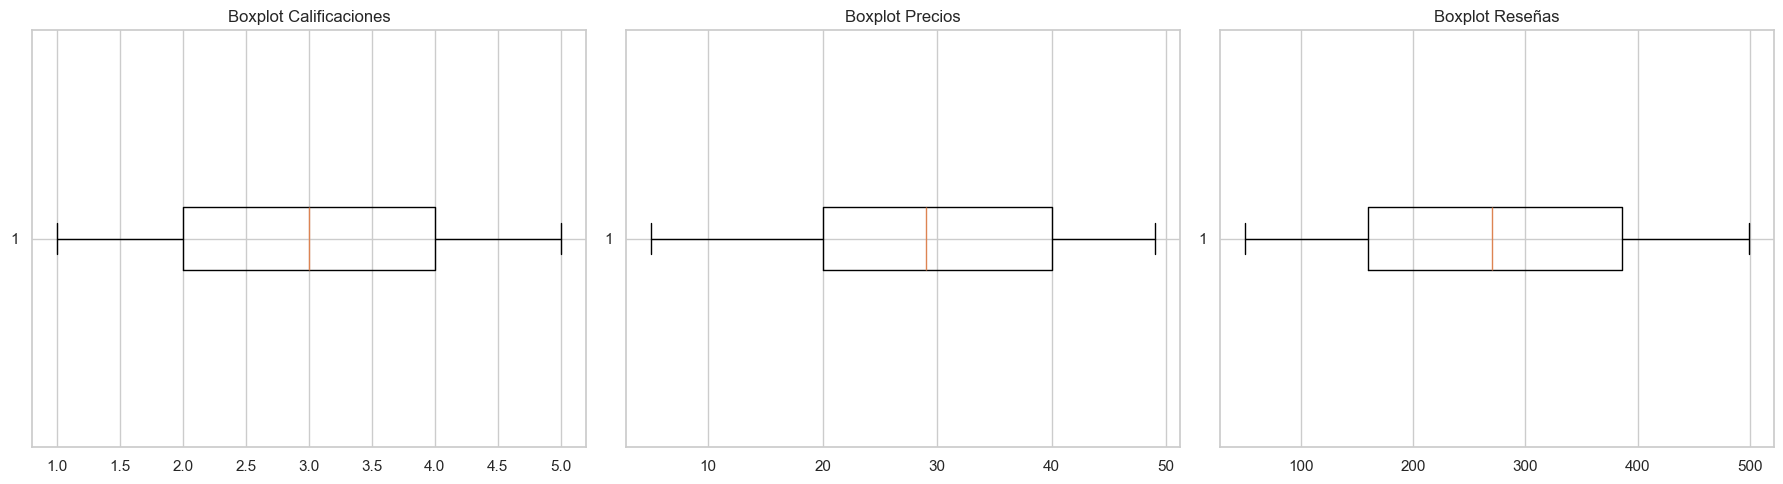

In [17]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(dataset['Calificación'], vert=False)
axes[0].set_title('Boxplot Calificaciones')

axes[1].boxplot(dataset['Precio promedio (USD)'], vert=False)
axes[1].set_title('Boxplot Precios')

axes[2].boxplot(dataset['Número de reseñas'], vert=False)
axes[2].set_title('Boxplot Reseñas')

plt.tight_layout()
plt.show()


* El Boxplot de las Calificaciones se observa que la mediana está cerca de 3, lo que indica que la mayoría de los restaurantes tienen una calificación promedio intermedia, tambien el rango intercuartílico va aproximadamente de 2 a 4, mostrando una dispersión moderada.

* El Boxplot de Precios la mediana se acerca a los 30 USD, y el rango intercuartílico va de 20 a 40 USD. Esto indica que la mayoría de los restaurantes tienen precios medios, con pocos casos muy baratos o muy caros y en los extremos del gráfico muestran que hay algunos restaurantes con precios fuera del rango típico, pero no excesivos.

* El Boxplot de Reseñas La mediana está cerca de 300 reseñas, con una dispersión amplia entre 100 y 500. Esto refleja una alta variabilidad en la popularidad algunos restaurantes reciben muchas reseñas, mientras otros apenas tienen unas pocas.


Categorías de comida más populares:
Categoría
Peruana       166
Mexicana      148
China         146
Francesa      146
Italiana      135
Japonesa      131
Colombiana    128
Name: count, dtype: int64


C:\Users\edwin\AppData\Local\Temp\ipykernel_18172\3697723613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\edwin\AppData\Local\Temp\ipykernel_18172\3697723613.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


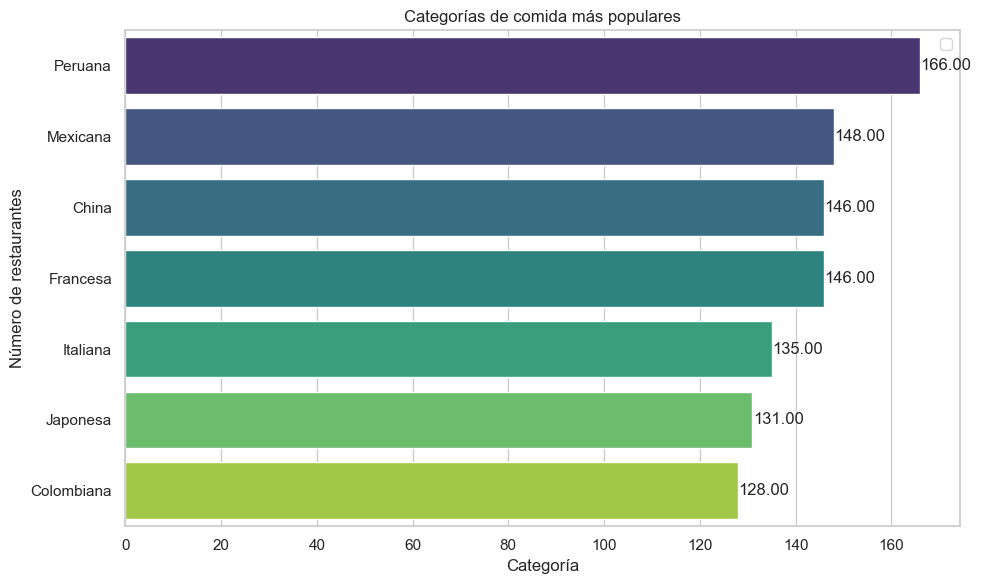

In [21]:
# Contar restaurantes por categoría
categorias_populares = dataset['Categoría'].value_counts()

print("Categorías de comida más populares:")
print(categorias_populares)

# Crear gráfico con Seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    x=categorias_populares.values,
    y=categorias_populares.index,
    palette="viridis"
)

# Añadir título y etiquetas
plt.title("Categorías de comida más populares")
plt.xlabel("Categoría")
plt.ylabel("Número de restaurantes")


# Mostrar valores en cada barra
for index, value in enumerate(categorias_populares.values):
    plt.text(value + 0.05, index, f"{value:.2f}", va='center')

# Mostrar leyenda
plt.legend()

plt.tight_layout()
plt.show()


Predomina la comida peruana con 166 restaurantes, la gastronomía peruana lidera el ranking.<br>
Competencia cercana entre cocinas mexicana, china y francesa las tres rondan los 145–150 restaurantes, lo que indica una oferta equilibrada.<br>
Cocinas italiana, japonesa y colombiana aunque tienen menos restaurantes, siguen siendo populares y representativas. La cocina colombiana, con 128 restaurantes, mantiene una buena presencia local frente a las opciones extranjeras.<br>
en generAL No hay categorías con valores extremos o fuera de escala, lo que sugiere una diversidad gastronómica estable. La diferencia entre la más y la menos popular (Peruana vs Colombiana) no es tan grande, lo que indica un mercado competitivo.

* Departamentos de Colombia con mayor concentración de restaurantes.Para se necesitas que el dataset tenga una columna que indique el departamento. Se debe hacer una georreferenciación inversa (reverse geocoding) con librerías como geopandas o geopy para obtener el departamento a partir de las coordenadas.

In [ ]:
# Inicializar geocodificador
geolocator = Nominatim(user_agent="geoapi")

# Función para obtener departamento

def obtener_departamento(lat, lon):
    try:
        location = geolocator.reverse((lat, lon), language="es")
        if location and 'address' in location.raw:
            return location.raw['address'].get('state', None)
    except:
        return None

# Crear nueva columna con el departamento
dataset['Departamento'] = dataset.apply(lambda row: obtener_departamento(row['Latitud'], row['Longitud']), axis=1)

'''
#Cargar shapefile de departamentos de Colombia
departamentos = gpd.read_file("COLOMBIA.shp")

#Convertir el dataset a GeoDataFrame
gdf = gpd.GeoDataFrame(
    dataset,
    geometry=gpd.points_from_xy(dataset['Longitud'], dataset['Latitud']),
    crs="EPSG:4326"   # sistema de coordenadas WGS84
)

# Hacer el cruce espacial (spatial join)
gdf = gpd.sjoin(gdf, departamentos[['DPTO_CNMBR','geometry']], how="left", predicate="within")

# Crear nueva columna con el nombre del departamento
dataset['Departamento'] = gdf['DPTO_CNMBR']
'''
#Verificar resultados
print("Departamentos obtenidos:")
print(dataset[['Nombre','Latitud','Longitud','Departamento']].head(20))


c:\Users\edwin\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopy\point.py:488: UserWarning: Latitude normalization has been prohibited in the newer versions of geopy, because the normalized value happened to be on a different pole, which is probably not what was meant. If you pass coordinates as positional args, please make sure that the order is (latitude, longitude) or (y, x) in Cartesian terms.
  return cls(*args)


: 

In [ ]:
#print(departamentos.columns)



Index(['OBJECTID', 'DPTO_CCDGO', 'DPTO_NANO_', 'DPTO_CNMBR', 'DPTO_CACTO',
       'DPTO_NAREA', 'DPTO_CSMBL', 'DPTO_NANO', 'PAIS_PAIS_', 'SHAPE_Leng',
       'SHAPE_Area', 'geometry'],
      dtype='object')


In [32]:
print(dataset['Departamento'].unique())

['CAQUETA' nan 'PUTUMAYO']


In [ ]:
# Contar restaurantes por departamento
departamentos_populares = dataset['Departamento'].value_counts()

print("Departamentos con mayor concentración de restaurantes:")
print(departamentos_populares.head(10))




Departamentos con mayor concentración de restaurantes:
Departamento
Tolima                      89
Antioquia                   47
Cundinamarca                34
Valle del Cauca             32
Caldas                      28
Chocó                       24
Risaralda                   17
Meta                        12
Bogotá, Distrito Capital    10
Quindío                      7
Name: count, dtype: int64


C:\Users\edwin\AppData\Local\Temp\ipykernel_31048\2129970248.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\edwin\AppData\Local\Temp\ipykernel_31048\2129970248.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


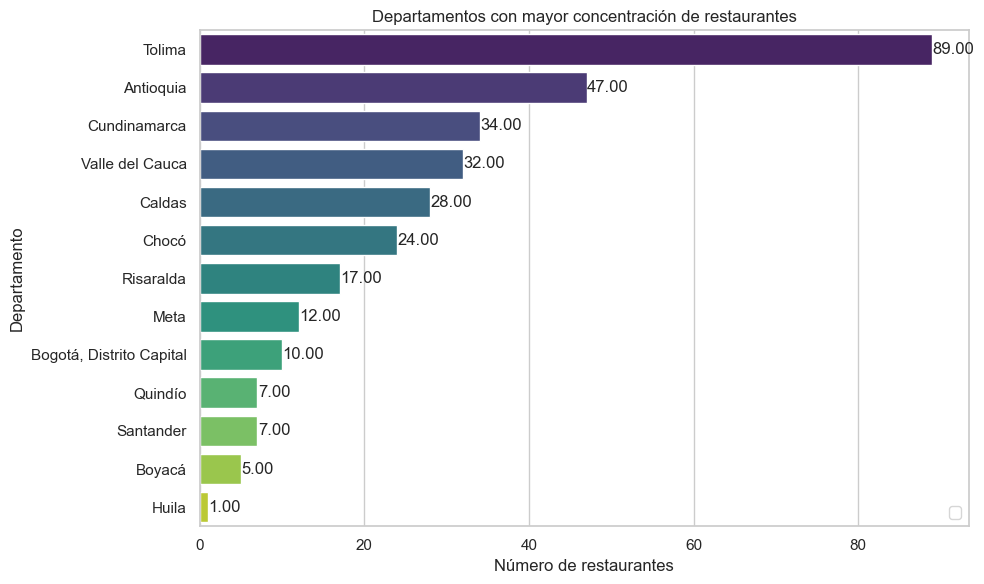

In [ ]:
# Crear gráfico con Seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    x=departamentos_populares.values,
    y=departamentos_populares.index,
    palette="viridis"
)

# Añadir título y etiquetas
plt.title("Departamentos con mayor concentración de restaurantes")
plt.xlabel("Número de restaurantes")
plt.ylabel("Departamento")


# Mostrar valores en cada barra
for index, value in enumerate(departamentos_populares.values):
    plt.text(value + 0.05, index, f"{value:.2f}", va='center')

# Mostrar leyenda
plt.legend()

plt.tight_layout()
plt.show()

* Para identificar qué categorías de comida obtienen las mejores calificaciones, hay que agrupar por categoría y calcular la media de la columna Calificación.

Promedio de calificaciones por categoría:
Categoría
Colombiana    3.124219
Italiana      3.068889
China         3.027397
Japonesa      2.992366
Mexicana      2.972297
Francesa      2.913014
Peruana       2.848193
Name: Calificación, dtype: float64
Media global de todas las calificaciones: 2.9861999999999997


C:\Users\edwin\AppData\Local\Temp\ipykernel_18172\2848904036.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


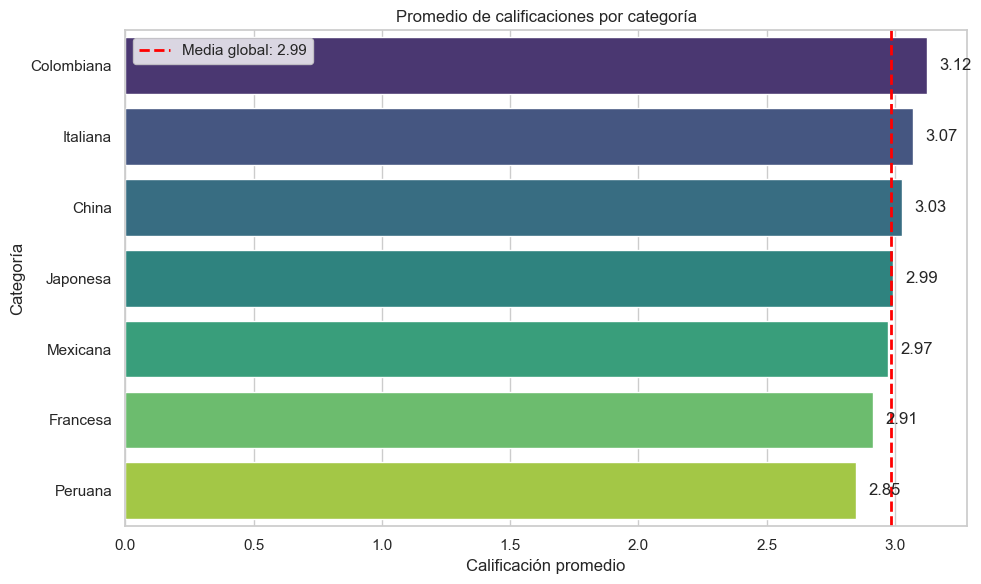

In [20]:
# Agrupar por categoría y calcular la media de calificación
calificaciones_por_categoria = dataset.groupby('Categoría')['Calificación'].mean().sort_values(ascending=False)

print("Promedio de calificaciones por categoría:")
print(calificaciones_por_categoria)

# Calcular la media global
media_global = dataset['Calificación'].mean()
print("Media global de todas las calificaciones:", media_global)

# Crear gráfico con Seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    x=calificaciones_por_categoria.values,
    y=calificaciones_por_categoria.index,
    palette="viridis"
)

# Añadir título y etiquetas
plt.title("Promedio de calificaciones por categoría")
plt.xlabel("Calificación promedio")
plt.ylabel("Categoría")

# Añadir línea vertical con la media global
plt.axvline(media_global, color='red', linestyle='--', linewidth=2, label=f'Media global: {media_global:.2f}')

# Mostrar valores en cada barra
for index, value in enumerate(calificaciones_por_categoria.values):
    plt.text(value + 0.05, index, f"{value:.2f}", va='center')

# Mostrar leyenda
plt.legend()

plt.tight_layout()
plt.show()


* Para identificar en qué departamento se encuentran los restaurantes más caros, se nececita analizar la columna Precio promedio (USD) agrupada por Departamento y calcular el promedio o el máximo de cada grupo.

Promedio de precios por departamento:
Departamento
Huila                       46.000000
Meta                        35.250000
Santander                   35.000000
Boyacá                      33.800000
Bogotá, Distrito Capital    32.500000
Caldas                      32.214286
Cundinamarca                30.941176
Quindío                     30.857143
Antioquia                   30.106383
Chocó                       29.708333
Name: Precio promedio (USD), dtype: float64


C:\Users\edwin\AppData\Local\Temp\ipykernel_31048\2975295765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


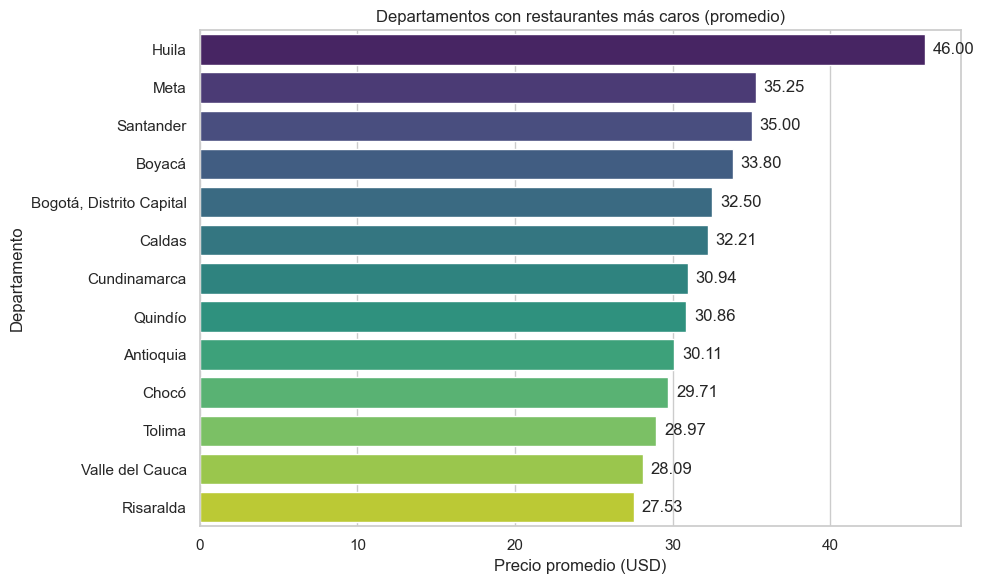

In [ ]:
# Agrupar por departamento y calcular el promedio de precios
precios_por_departamento = dataset.groupby('Departamento')['Precio promedio (USD)'].mean().sort_values(ascending=False)

print("Promedio de precios por departamento:")
print(precios_por_departamento.head(10))

# Visualización con Seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    x=precios_por_departamento.values,
    y=precios_por_departamento.index,
    palette="viridis"
)

plt.title("Departamentos con restaurantes más caros (promedio)")
plt.xlabel("Precio promedio (USD)")
plt.ylabel("Departamento")

# Mostrar valores en cada barra
for index, value in enumerate(precios_por_departamento.values):
    plt.text(value + 0.5, index, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()


# Actividad 2 Visualización Geoespacial con Folium<a id="3"></a>

# Actividad 3 Creación de Gráficos Interactivos y Dashboard con Plotly y Dash<a id="4"></a>

# Actividad 4 Completar la Certificación IBM Cognitive<a id="4"></a>